In [69]:
import pandas as pd
import numpy as np
import os
import typing
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler

In [70]:
# Define file paths
population_file = '../Data/population_with_latlong.csv'
dengue_file = '../Data/reshaped_dengue_data.csv'

# Load the datasets into pandas DataFrames
population_df = pd.read_csv(population_file)
dengue_df = pd.read_csv(dengue_file)

dengue_array = dengue_df.drop("date", axis=1).values.astype("float32")
print(f"(timesteps, localities): {dengue_array.shape}")

# Define the split point
train_val_size = 200

# Create the training/validation set and the final hold-out test set
train_val_array = dengue_array[:train_val_size]
test_array = dengue_array[train_val_size:]

print(f"\nTraining/Validation set shape: {train_val_array.shape}")
print(f"Hold-Out Test set shape: {test_array.shape}")

(timesteps, localities): (228, 558)

Training/Validation set shape: (200, 558)
Hold-Out Test set shape: (28, 558)


Preprocess

In [71]:
# def preprocess(data_array: np.ndarray):
#     """
#     Splits data into train/val sets based on fractions and normalizes the data.
#     """
#     num_time_steps = data_array.shape[0]
#     num_train = 160
#     num_val = 34

#     # Split the data
#     train_array = data_array[:num_train]
#     val_array = data_array[num_train : num_train + num_val]
#     # The rest of the data can be used as a test set if needed
#     # test_array = data_array[num_train + num_val:]

#     # Normalize based on the training data ONLY to prevent data leakage
#     mean = train_array.mean(axis=0)
#     std = train_array.std(axis=0)

#     # Handle cases where standard deviation is zero to avoid division by zero
#     std[std == 0] = 1.0

#     train_array_normalized = (train_array - mean) / std
#     val_array_normalized = (val_array - mean) / std
    
#     # We return the mean and std to de-normalize predictions later
#     return train_array_normalized, val_array_normalized, mean, std

# #Apply the preprocessing function to the data
# train_array, val_array, mean_vals, std_vals = preprocess(dengue_array)

# print(f"Train array shape: {train_array.shape}")
# print(f"Validation array shape: {val_array.shape}\n")

Creating tf dataset

In [72]:
# Define hyperparameters for creating the time-series sequences
input_sequence_length = 12
forecast_horizon = 3
batch_size = 32


# Define the function to create TensorFlow datasets
def create_tf_dataset(
    data_array: np.ndarray,
    input_sequence_length: int,
    forecast_horizon: int,
    batch_size: int = 32,
    shuffle=True,
    multi_horizon=True,
):
    """Creates a TensorFlow dataset from a NumPy array."""
    
    # Create inputs using sliding windows on the data array
    inputs = tf.keras.preprocessing.timeseries_dataset_from_array(
        np.expand_dims(data_array[:-forecast_horizon], axis=-1),
        None,
        sequence_length=input_sequence_length,
        shuffle=False,
        batch_size=batch_size,
    )

    # Determine the starting point for the target sequences
    target_offset = (
        input_sequence_length if multi_horizon else input_sequence_length + forecast_horizon - 1
    )
    target_seq_length = forecast_horizon if multi_horizon else 1
    
    # Create targets using sliding windows
    targets = tf.keras.preprocessing.timeseries_dataset_from_array(
        data_array[target_offset:],
        None,
        sequence_length=target_seq_length,
        shuffle=False,
        batch_size=batch_size,
    )

    # Zip inputs and targets together into a single dataset
    dataset = tf.data.Dataset.zip((inputs, targets))
    if shuffle:
        dataset = dataset.shuffle(100)

    # Prefetch and cache for performance
    return dataset.prefetch(16).cache()


# # Create the final training and validation datasets
# train_dataset = create_tf_dataset(
#     train_array, input_sequence_length, forecast_horizon, batch_size, multi_horizon=False
# )
# val_dataset = create_tf_dataset(
#     val_array, input_sequence_length, forecast_horizon, batch_size, shuffle=False, multi_horizon=False
# )

# print("TensorFlow datasets created successfully.")

Gravity Model

In [73]:
def create_sparse_gravity_matrix(
    df: pd.DataFrame, 
    population_col='population', 
    lat_col='latitude', 
    lon_col='longitude',
    p_cutoff=90 # Keep the top 10% of all weighted edges (100 - 90)
):
    """
    Creates a sparse, row-normalized, weighted adjacency matrix based on a gravity model,
    keeping only the edges with weights above a certain percentile cutoff.
    """
    num_nodes = len(df)
    populations = df[population_col].values
    coords = np.radians(df[[lat_col, lon_col]].values)

    # 1. Calculate the pairwise Haversine distance matrix
    lat = coords[:, 0]
    lon = coords[:, 1]
    dlat = lat[:, np.newaxis] - lat
    dlon = lon[:, np.newaxis] - lon
    a = np.sin(dlat / 2.0)**2 + np.cos(lat[:, np.newaxis]) * np.cos(lat) * np.sin(dlon / 2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    distance_matrix = 6371 * c

    # 2. Calculate the population interaction term
    pop_matrix = np.outer(populations, populations)

    # 3. Calculate the gravity model scores
    with np.errstate(divide='ignore', invalid='ignore'):
        gravity_matrix = pop_matrix / (distance_matrix**2)
    np.fill_diagonal(gravity_matrix, 0)
    gravity_matrix[~np.isfinite(gravity_matrix)] = 0
    
    # --- Sparsify the Graph ---
    # 4. Keep only the most significant edges
    all_edges = gravity_matrix[gravity_matrix > 0]
    if len(all_edges) == 0:
        return np.zeros_like(gravity_matrix) # Return empty matrix if no edges exist
        
    cutoff_value = np.percentile(all_edges, p_cutoff)
    
    sparse_gravity_matrix = gravity_matrix.copy()
    sparse_gravity_matrix[sparse_gravity_matrix < cutoff_value] = 0

    # 5. Re-normalize the sparse matrix by row
    row_sums = sparse_gravity_matrix.sum(axis=1)
    row_sums[row_sums == 0] = 1.0 # Avoid division by zero
    
    normalized_adj_matrix = sparse_gravity_matrix / row_sums[:, np.newaxis]
    
    return normalized_adj_matrix

# --- Define the GraphInfo Class ---
class GraphInfo:
    def __init__(self, edges: typing.Tuple[list, list], edge_weights: list, num_nodes: int):
        self.edges = edges
        self.edge_weights = edge_weights
        self.num_nodes = num_nodes

# --- Initialize the Graph ---
# This is a hyperparameter you can tune
p_cutoff = 97 
weighted_adjacency_matrix = create_sparse_gravity_matrix(population_df, p_cutoff=p_cutoff)

# Find the edges and their corresponding weights from the sparse matrix
node_indices, neighbor_indices = np.where(weighted_adjacency_matrix > 0)
edge_weights = weighted_adjacency_matrix[node_indices, neighbor_indices]

graph = GraphInfo(
    edges=(node_indices.tolist(), neighbor_indices.tolist()),
    edge_weights=edge_weights.tolist(),
    num_nodes=weighted_adjacency_matrix.shape[0],
)

print(f"Sparse gravity graph initialized with a {p_cutoff}th percentile cutoff.")
print(f"Graph has {graph.num_nodes} nodes and {len(graph.edges[0])} edges.")

Sparse gravity graph initialized with a 97th percentile cutoff.
Graph has 558 nodes and 9326 edges.


GraphConv

In [74]:
class GraphConv(layers.Layer):
    def __init__(
        self,
        in_feat,
        out_feat,
        graph_info: GraphInfo,
        combination_type="concat",
        activation: typing.Optional[str] = None,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.in_feat = in_feat
        self.out_feat = out_feat
        self.graph_info = graph_info
        self.combination_type = combination_type
        
        self.edge_weights = tf.constant(graph_info.edge_weights, dtype="float32")

        self.weight = tf.Variable(
            initial_value=keras.initializers.glorot_uniform()(
                shape=(in_feat, out_feat), dtype="float32"
            ),
            trainable=True,
        )
        self.activation = layers.Activation(activation)

    def aggregate(self, neighbour_representations: tf.Tensor):
        """
        Performs a weighted aggregation of neighbor features.
        The formula is: sum(features * weights) / sum(weights)
        """
        # Reshape edge weights to multiply with neighbor features
        weights_reshaped = tf.reshape(self.edge_weights, (-1, 1, 1, 1))
        weighted_neighbors = neighbour_representations * weights_reshaped
        
        # Calculate the numerator of the weighted mean
        numerator = tf.math.unsorted_segment_sum(
            data=weighted_neighbors,
            segment_ids=self.graph_info.edges[0],
            num_segments=self.graph_info.num_nodes
        )
        
        # --- CORRECTED PART ---
        # Calculate the denominator (sum of weights for each node)
        denominator = tf.math.unsorted_segment_sum(
            data=self.edge_weights,
            segment_ids=self.graph_info.edges[0],
            num_segments=self.graph_info.num_nodes
        )
        
        # Reshape denominator for broadcasting across all dimensions
        # Shape changes from (num_nodes,) to (num_nodes, 1, 1, 1)
        denominator_reshaped = tf.reshape(denominator, (-1, 1, 1, 1))
        
        # Avoid division by zero
        denominator_reshaped = tf.where(denominator_reshaped == 0, 1.0, denominator_reshaped)
        
        return numerator / denominator_reshaped

    def compute_nodes_representation(self, features: tf.Tensor):
        return tf.matmul(features, self.weight)

    def compute_aggregated_messages(self, features: tf.Tensor):
        neighbour_representations = tf.gather(features, self.graph_info.edges[1])
        aggregated_messages = self.aggregate(neighbour_representations)
        return tf.matmul(aggregated_messages, self.weight)

    def update(self, nodes_representation: tf.Tensor, aggregated_messages: tf.Tensor):
        if self.combination_type == "concat":
            h = tf.concat([nodes_representation, aggregated_messages], axis=-1)
        elif self.combination_type == "add":
            h = nodes_representation + aggregated_messages
        else:
            raise ValueError(f"Invalid combination type: {self.combination_type}.")
        return self.activation(h)

    def call(self, features: tf.Tensor):
        nodes_representation = self.compute_nodes_representation(features)
        aggregated_messages = self.compute_aggregated_messages(features)
        return self.update(nodes_representation, aggregated_messages)

In [75]:
class LSTMGC(layers.Layer):
    """Layer comprising a graph convolution layer followed by an LSTM and dense layer."""

    def __init__(
        self,
        in_feat,
        out_feat,
        lstm_units: int,
        input_seq_len: int,
        output_seq_len: int,
        graph_info: GraphInfo,
        **kwargs,
    ):
        super().__init__(**kwargs)

        self.graph_conv = GraphConv(in_feat, out_feat, graph_info)
        self.lstm = layers.LSTM(lstm_units, activation="relu", dropout=0.25)
        self.dense = layers.Dense(output_seq_len, kernel_regularizer=keras.regularizers.l2(0.001))
        self.input_seq_len = input_seq_len
        self.output_seq_len = output_seq_len

    def call(self, inputs):
        """Forward pass."""
        # Reshape for GraphConv
        inputs = tf.transpose(inputs, [2, 0, 1, 3])

        gcn_out = self.graph_conv(inputs)
        
        shape = tf.shape(gcn_out)
        num_nodes, batch_size, input_seq_len, out_feat = (
            shape[0], shape[1], shape[2], shape[3]
        )

        # Reshape for LSTM
        gcn_out = tf.reshape(gcn_out, (batch_size * num_nodes, input_seq_len, out_feat))
        lstm_out = self.lstm(gcn_out)

        # Final prediction
        dense_output = self.dense(lstm_out)
        output = tf.reshape(dense_output, (num_nodes, batch_size, self.output_seq_len))
        
        # Reshape back to a user-friendly format
        return tf.transpose(output, [1, 2, 0])

print("LSTMGC layer defined successfully.")

LSTMGC layer defined successfully.


In [76]:
# # --- New Cell for Cross-Validation ---
# from sklearn.model_selection import TimeSeriesSplit
# from sklearn.preprocessing import MinMaxScaler
# import time

# # --- 1. Define Model Hyperparameters ---
# in_feat = 1
# out_feat = 4
# lstm_units = 32
# epochs = 20
# output_sequence_length = 1
# input_sequence_length = 12
# forecast_horizon = 1
# batch_size = 32

# # --- 2. Set up Time Series Cross-Validation ---
# n_splits = 3
# tscv = TimeSeriesSplit(n_splits=n_splits)

# validation_scores = []
# print(f"Starting Time Series Cross-Validation with {n_splits} splits...")
# print("This will take a few moments as the model is trained multiple times.")

# for fold, (train_indices, val_indices) in enumerate(tscv.split(train_val_array)):
#     print(f"\n--- FOLD {fold + 1}/{n_splits} ---")
    
#     # Create and preprocess data for the current fold
#     train_fold, val_fold = train_val_array[train_indices], train_val_array[val_indices]
#     scaler = MinMaxScaler()
#     train_fold_norm = scaler.fit_transform(train_fold)
#     val_fold_norm = scaler.transform(val_fold)
    
#     # Create TensorFlow datasets for the current fold
#     train_dataset = create_tf_dataset(train_fold_norm, input_sequence_length, forecast_horizon, batch_size, multi_horizon=False)
#     val_dataset = create_tf_dataset(val_fold_norm, input_sequence_length, forecast_horizon, batch_size, shuffle=False, multi_horizon=False)
    
#     # Re-initialize and train the model for this fold
#     input_layer = layers.Input(shape=(input_sequence_length, graph.num_nodes, in_feat))
#     st_gcn_layer = LSTMGC(in_feat, out_feat, lstm_units, input_sequence_length, output_sequence_length, graph)
#     outputs = st_gcn_layer(input_layer)
#     model = keras.models.Model(inputs=input_layer, outputs=outputs)
    
#     model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss=keras.losses.MeanSquaredError())
    
#     model.fit(train_dataset, epochs=epochs, validation_data=val_dataset,
#               callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)])
    
#     # Evaluate and store the score for this fold
#     x_val, y_val_true_norm = next(iter(val_dataset))
#     y_val_pred_norm = model.predict(x_val)

#     pred_denorm = scaler.inverse_transform(y_val_pred_norm.reshape(-1, graph.num_nodes)).reshape(y_val_pred_norm.shape)
#     true_denorm = scaler.inverse_transform(y_val_true_norm.numpy().reshape(-1, graph.num_nodes)).reshape(y_val_true_norm.shape)
    
#     fold_mae = np.mean(np.abs(pred_denorm - true_denorm))
#     validation_scores.append(fold_mae)
#     print(f"MAE for Fold {fold + 1}: {fold_mae:.2f} cases")

# # --- Final Cross-Validation Performance ---
# print("\n--- Cross-Validation Summary ---")
# print(f"Validation MAE scores for each fold: {[f'{s:.2f}' for s in validation_scores]}")
# print(f"Average Validation MAE: {np.mean(validation_scores):.2f} cases")

In [77]:
# --- 1. Define Model Hyperparameters ---
in_feat = 1
out_feat = 4
lstm_units = 32
epochs = 30
output_sequence_length = 1
input_sequence_length = 12
forecast_horizon = 1
batch_size = 32

# --- New Cell for Final Model Training and Testing ---
print("\n--- Final Model Training ---")

# 1. Split train_val_array into train (80%) and validation (20%)
train_size = int(0.8 * len(train_val_array))
train_array = train_val_array[:train_size]
val_array = train_val_array[train_size:]

print(f"Training set: {train_array.shape[0]} timesteps")
print(f"Validation set: {val_array.shape[0]} timesteps")

# 2. Normalize data (fit scaler on training data only to prevent data leakage)
full_train_val_scaler = MinMaxScaler()
train_norm = full_train_val_scaler.fit_transform(train_array)
val_norm = full_train_val_scaler.transform(val_array)  # Use same scaler as training

# 3. Create separate datasets for training and validation
train_dataset = create_tf_dataset(train_norm, input_sequence_length, forecast_horizon, batch_size, multi_horizon=False, shuffle=True)
val_dataset = create_tf_dataset(val_norm, input_sequence_length, forecast_horizon, batch_size, multi_horizon=False, shuffle=False)

# 4. Re-initialize and train the final model with validation
final_input_layer = layers.Input(shape=(input_sequence_length, graph.num_nodes, in_feat))
final_st_gcn_layer = LSTMGC(in_feat, out_feat, lstm_units, input_sequence_length, output_sequence_length, graph)
final_outputs = final_st_gcn_layer(final_input_layer)
final_model = keras.models.Model(inputs=final_input_layer, outputs=final_outputs)
final_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0005), loss=keras.losses.MeanAbsoluteError())

print(f"\nTraining model for up to {epochs} epochs with early stopping (patience=8)...")
print("Monitoring validation loss for early stopping...\n")

history = final_model.fit(
    train_dataset, 
    validation_data=val_dataset,
    epochs=epochs, 
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss", 
            patience=8, 
            restore_best_weights=True,
            verbose=1
        )
    ],
    verbose=1
)

print("\nTraining complete!")



--- Final Model Training ---
Training set: 160 timesteps
Validation set: 40 timesteps



Training model for up to 30 epochs with early stopping (patience=8)...
Monitoring validation loss for early stopping...

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 458ms/step - loss: 0.0684 - val_loss: 0.4013
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 429ms/step - loss: 0.0653 - val_loss: 0.3893
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 418ms/step - loss: 0.0640 - val_loss: 0.3825
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 386ms/step - loss: 0.0627 - val_loss: 0.3803
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 405ms/step - loss: 0.0616 - val_loss: 0.3743
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 393ms/step - loss: 0.0608 - val_loss: 0.3710
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 359ms/step - loss: 0.0601 - val_loss: 0.3692
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 361ms/step - loss: 0.0596 - val_loss: 0.3683
Epoch 9/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 368ms/step - loss: 0.0591 - val_loss: 0.3701
Epoch 10/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 318ms/step - loss: 0.0587 - val_loss: 0.3863
Epoch 11/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 

In [78]:
# --- Final Evaluation on the Hold-Out Test Set ---
print("\n--- Final Evaluation on Hold-Out Test Set ---")

# 3. Prepare the test dataset
test_norm = full_train_val_scaler.transform(test_array) # Use the SAME scaler
test_dataset = create_tf_dataset(test_norm, input_sequence_length, forecast_horizon, batch_size, shuffle=False, multi_horizon=False)

# 4. Evaluate the model
x_test, y_test_true_norm = next(iter(test_dataset))
y_test_pred_norm = final_model.predict(x_test)

# De-normalize using the scaler fit on the training/validation data
pred_denorm_stgcn = full_train_val_scaler.inverse_transform(y_test_pred_norm.reshape(-1, graph.num_nodes)).reshape(y_test_pred_norm.shape)
true_denorm_stgcn = full_train_val_scaler.inverse_transform(y_test_true_norm.numpy().reshape(-1, graph.num_nodes)).reshape(y_test_true_norm.shape)
pred_denorm_stgcn = np.clip(pred_denorm_stgcn, 0, None)  # Ensure no negative predictions

# 5. Report final metrics
# Mean Absolute Error (MAE)
final_mae = np.mean(np.abs(pred_denorm_stgcn - true_denorm_stgcn))

# Symmetric Mean Absolute Percentage Error (sMAPE)
epsilon = 1e-8 # Small value to avoid division by zero
final_smape = np.mean(2 * np.abs(pred_denorm_stgcn - true_denorm_stgcn) / (np.abs(true_denorm_stgcn) + np.abs(pred_denorm_stgcn) + epsilon)) * 100

# Mean Absolute Scaled Error (MASE)
# The scaling factor is the MAE of a naive forecast on the *training* data
naive_error = np.mean(np.abs(train_val_array[1:] - train_val_array[:-1]))
final_mase = final_mae / naive_error

print(f"Final Hold-Out Test MAE: {final_mae:.2f} cases")
print(f"Final Hold-Out Test sMAPE: {final_smape:.2f}%")
print(f"Final Hold-Out Test MASE: {final_mase:.2f} (Value < 1 is better than a naive forecast)")



--- Final Evaluation on Hold-Out Test Set ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step
Final Hold-Out Test MAE: 152.63 cases
Final Hold-Out Test sMAPE: 116.67%
Final Hold-Out Test MASE: 2.38 (Value < 1 is better than a naive forecast)


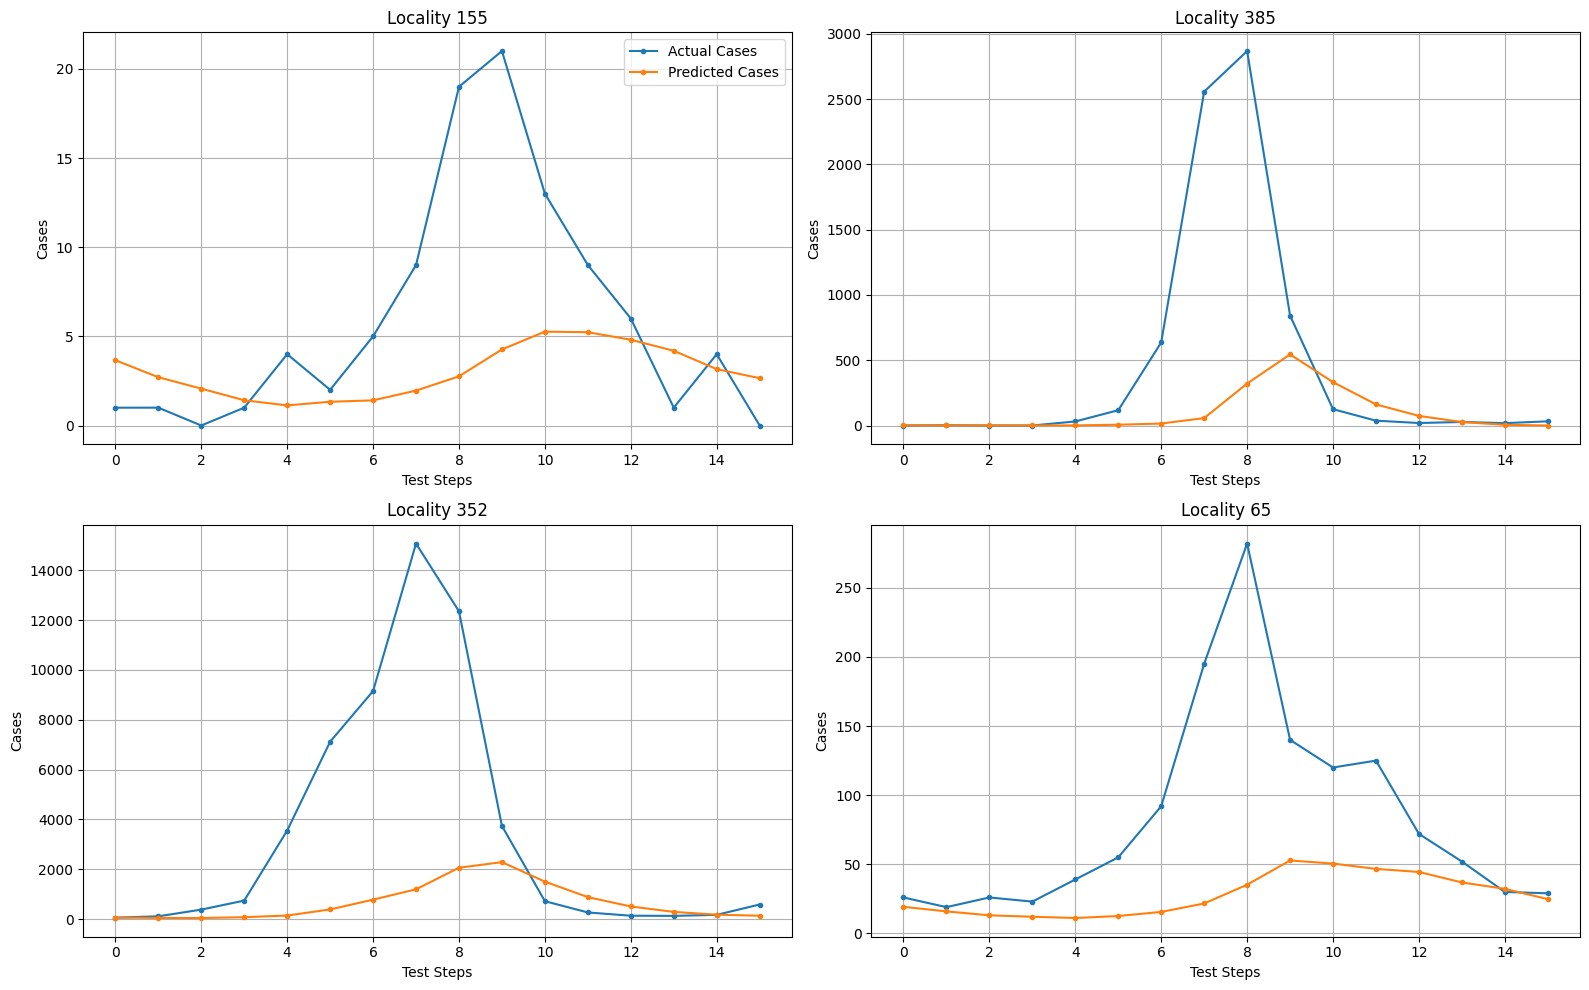

In [79]:
# Pick 4 random locality indices
num_localities = true_denorm_stgcn.shape[2]
localities = np.random.choice(num_localities, size=4, replace=False)

plt.figure(figsize=(16, 10))

for i, loc in enumerate(localities):
    plt.subplot(2, 2, i+1)
    plt.plot(true_denorm_stgcn[:, :, loc].flatten(), label="Actual Cases", marker='.')
    plt.plot(pred_denorm_stgcn[:, :, loc].flatten(), label="Predicted Cases", marker='.')
    plt.title(f'Locality {loc}')
    plt.xlabel("Test Steps")
    plt.ylabel("Cases")
    plt.grid(True)
    if i == 0:
        plt.legend()

plt.tight_layout()
plt.show()

In [80]:
# --- 1. Define and Compile the Multi-Variate LSTM Model ---
print("--- Building Multi-Variate LSTM Model (No Graph) ---")

lstm_input_layer = layers.Input(shape=(input_sequence_length, graph.num_nodes))
lstm_layer = layers.LSTM(32)(lstm_input_layer)
lstm_output_layer = layers.Dense(graph.num_nodes)(lstm_layer)
lstm_model = keras.models.Model(inputs=lstm_input_layer, outputs=lstm_output_layer)

lstm_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mean_absolute_error')
lstm_model.summary()

# --- 2. Prepare Data for a Standard LSTM ---
def adjust_shapes_for_lstm(x, y):
    return tf.squeeze(x, axis=-1), tf.squeeze(y, axis=1)

lstm_full_train_dataset = full_train_dataset.map(adjust_shapes_for_lstm)
lstm_test_dataset = test_dataset.map(adjust_shapes_for_lstm)

# --- 3. Train the LSTM Model ---
print("\n--- Training Multi-Variate LSTM Model ---")
lstm_model.fit(
    lstm_full_train_dataset,
    epochs=100,
    callbacks=[keras.callbacks.EarlyStopping(monitor="loss", patience=10, restore_best_weights=True)],
    verbose=0
)

# --- 4. Evaluate and Store Predictions ---
print("\n--- Evaluating Multi-Variate LSTM on Test Set ---")
x_test_lstm, y_test_true_norm_lstm = next(iter(lstm_test_dataset))
y_test_pred_norm_lstm = lstm_model.predict(x_test_lstm)

# De-normalize and store predictions in a new variable
pred_denorm_lstm = full_train_val_scaler.inverse_transform(y_test_pred_norm_lstm)
true_denorm_lstm = full_train_val_scaler.inverse_transform(y_test_true_norm_lstm.numpy())
pred_denorm_lstm = np.maximum(0, pred_denorm_lstm)

# --- 5. Report Final Metrics ---
final_mae_lstm = np.mean(np.abs(pred_denorm_lstm - true_denorm_lstm))
epsilon = 1e-8
final_smape_lstm = np.mean(2 * np.abs(pred_denorm_lstm - true_denorm_lstm) / (np.abs(true_denorm_lstm) + np.abs(pred_denorm_lstm) + epsilon)) * 100
naive_error = np.mean(np.abs(train_val_array[1:] - train_val_array[:-1]))
final_mase_lstm = final_mae_lstm / naive_error

print("\n--- Multi-Variate LSTM Model Performance ---")
print(f"Final Hold-Out Test MAE: {final_mae_lstm:.2f} cases")
print(f"Final Hold-Out Test sMAPE: {final_smape_lstm:.2f}%")
print(f"Final Hold-Out Test MASE: {final_mase_lstm:.2f} (Value < 1 is better than naive)")

--- Building Multi-Variate LSTM Model (No Graph) ---


Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 12, 558)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_12 (LSTM)                  │ (None, 32)             │        75,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 558)            │        18,414 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,062 (367.43 KB)

 Trainable params: 94,062 (367.43 KB)

 Non-trainable params: 0 (0.00 B)


--- Training Multi-Variate LSTM Model ---

--- Evaluating Multi-Variate LSTM on Test Set ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step

--- Multi-Variate LSTM Model Performance ---
Final Hold-Out Test MAE: 179.42 cases
Final Hold-Out Test sMAPE: 133.95%
Final Hold-Out Test MASE: 2.80 (Value < 1 is better than naive)


In [81]:
# --- 1. Define Localities and Setup ---
localities_to_test = [10, 150, 300, 400]
ensemble_preds = {}
ensemble_true = {}
# Use lstm as it's simpler and effective for the ensemble
ensemble_lstm_units = 32 

# --- 2. Helper function for windowing ---
def create_windows(data, input_seq_len, forecast_horizon):
    X, y = [], []
    for i in range(len(data) - input_seq_len - forecast_horizon + 1):
        X.append(data[i:(i + input_seq_len), 0])
        y.append(data[i + input_seq_len + forecast_horizon - 1, 0])
    return np.array(X), np.array(y)

# --- 3. Loop, Train, and Predict for Each Selected Locality ---
print(f"--- Training Ensemble Models for 4 Localities: {localities_to_test} ---")

for i in localities_to_test:
    print(f"Training model for locality {i}...")
    
    single_locality_data = dengue_array[:, i].reshape(-1, 1)
    train_data = single_locality_data[:train_val_size]
    test_data = single_locality_data[train_val_size:]
    
    scaler_ensemble = MinMaxScaler()
    train_scaled = scaler_ensemble.fit_transform(train_data)
    test_scaled = scaler_ensemble.transform(test_data)
    
    X_train, y_train = create_windows(train_scaled, input_sequence_length, forecast_horizon)
    X_test, y_test = create_windows(test_scaled, input_sequence_length, forecast_horizon)
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    lstm_model = Sequential([
        layers.Input(shape=(input_sequence_length, 1)),
        layers.LSTM(ensemble_lstm_units, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1)
    ])
    lstm_model.compile(optimizer='adam', loss='mean_absolute_error')
    
    lstm_model.fit(X_train, y_train, epochs=100,
                  callbacks=[keras.callbacks.EarlyStopping(monitor='loss', patience=10)],
                  verbose=0)
    
    predictions_scaled = lstm_model.predict(X_test, verbose=0)
    ensemble_preds[i] = np.maximum(0, scaler_ensemble.inverse_transform(predictions_scaled))
    ensemble_true[i] = scaler_ensemble.inverse_transform(y_test.reshape(-1, 1))

# --- 4. Aggregate and Evaluate the Performance ---
all_predictions_np = np.concatenate([ensemble_preds[i] for i in localities_to_test])
all_true_values_np = np.concatenate([ensemble_true[i] for i in localities_to_test])

final_mae_ensemble = np.mean(np.abs(all_predictions_np - all_true_values_np))
epsilon = 1e-8
final_smape_ensemble = np.mean(2 * np.abs(all_predictions_np - all_true_values_np) / (np.abs(all_true_values_np) + np.abs(all_predictions_np) + epsilon)) * 100
naive_error = np.mean(np.abs(train_val_array[1:] - train_val_array[:-1]))
final_mase_ensemble = final_mae_ensemble / naive_error

print("\n--- Aggregate Performance of Ensemble Model (4 Localities) ---")
print(f"Final Test MAE: {final_mae_ensemble:.2f} cases")
print(f"Final Test sMAPE: {final_smape_ensemble:.2f}%")
print(f"Final Test MASE: {final_mase_ensemble:.2f} (Value < 1 is better than naive)")

--- Training Ensemble Models for 4 Localities: [10, 150, 300, 400] ---
Training model for locality 10...


NameError: name 'Sequential' is not defined

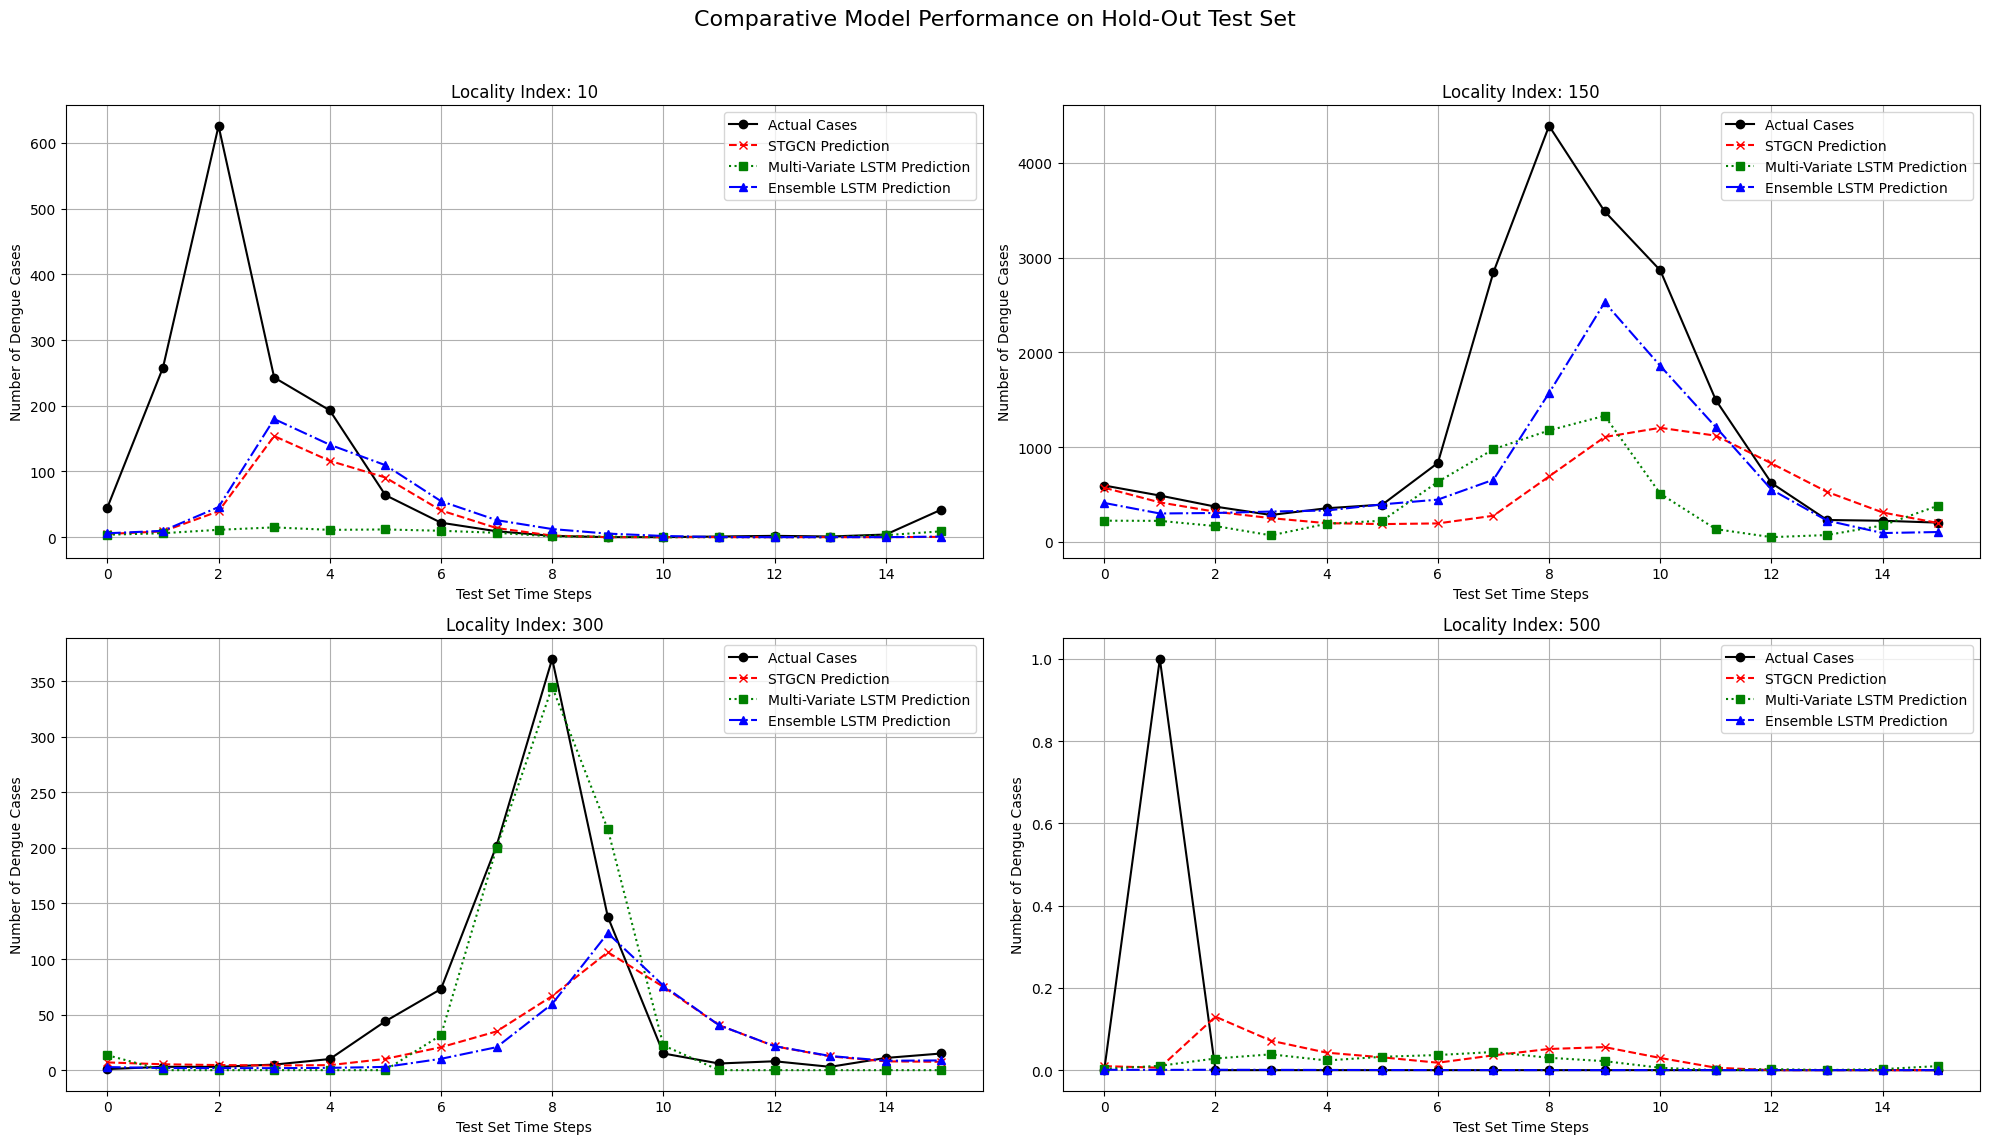

In [ ]:
# --- Plotting the Comparative Results ---
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('Comparative Model Performance on Hold-Out Test Set', fontsize=16)
axes = axes.flatten() # Flatten the 2x2 grid for easy iteration

for i, locality_idx in enumerate(localities_to_test):
    ax = axes[i]
    
    # Plot Actual Cases
    # Note: We use the test data from the ensemble for the true values
    ax.plot(ensemble_true[locality_idx].flatten(), label="Actual Cases", marker='o', linestyle='-', color='black')
    
    # Plot STGCN Predictions
    # We need to find the correct number of test samples to plot
    num_test_samples = len(ensemble_true[locality_idx])
    ax.plot(pred_denorm_stgcn[:num_test_samples, 0, locality_idx], label="STGCN Prediction", marker='x', linestyle='--', color='red')
    
    # Plot Multi-Variate LSTM Predictions
    ax.plot(pred_denorm_lstm[:num_test_samples, locality_idx], label="Multi-Variate LSTM Prediction", marker='s', linestyle=':', color='green')
    
    # Plot Ensemble Model Predictions
    ax.plot(ensemble_preds[locality_idx].flatten(), label="Ensemble LSTM Prediction", marker='^', linestyle='-.', color='blue')
    
    ax.set_title(f'Locality Index: {locality_idx}')
    ax.set_xlabel("Test Set Time Steps")
    ax.set_ylabel("Number of Dengue Cases")
    ax.legend()
    ax.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
import time

# --- 1. Define Hyperparameters and Setup ---
input_sequence_length = 12
forecast_horizon = 1
lstm_units = 32
epochs = 100
train_val_size = 200 # Using the same split point as before

# Select 25 localities spread evenly across the 558 indices
num_localities_to_test = 70
localities_to_test = np.linspace(0, dengue_array.shape[1] - 1, num_localities_to_test, dtype=int)

all_predictions = []
all_true_values = []

# --- 2. Helper function to create time-series windows ---
def create_windows(data, input_seq_len, forecast_horizon):
    X, y = [], []
    for i in range(len(data) - input_seq_len - forecast_horizon + 1):
        X.append(data[i:(i + input_seq_len), 0])
        y.append(data[i + input_seq_len + forecast_horizon - 1, 0])
    return np.array(X), np.array(y)

# --- 3. Loop through each locality, train a model, and predict ---
print(f"Starting to train an ensemble of {num_localities_to_test} independent LSTM models...")
start_time = time.time()

for i in localities_to_test:
    print(f"\rTraining model for locality {i}...", end="")

    # Isolate and split data for the current locality
    single_locality_data = dengue_array[:, i].reshape(-1, 1)
    train_data = single_locality_data[:train_val_size]
    test_data = single_locality_data[train_val_size:]

    # Scale data for this specific locality
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_data)
    test_scaled = scaler.transform(test_data)

    # Create time-series windows
    X_train, y_train = create_windows(train_scaled, input_sequence_length, forecast_horizon)
    X_test, y_test = create_windows(test_scaled, input_sequence_length, forecast_horizon)

    # Reshape input for LSTM layer
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    # Skip if there's no test data to predict on
    if len(X_test) == 0:
        continue

    # Build and train a new LSTM model
    lstm_model = Sequential([
        layers.Input(shape=(input_sequence_length, 1)),
        layers.GRU(lstm_units, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1)
    ])
    lstm_model.compile(optimizer='adam', loss='mean_absolute_error')

    lstm_model.fit(
        X_train, y_train,
        epochs=epochs,
        callbacks=[keras.callbacks.EarlyStopping(monitor='loss', patience=10)],
        verbose=0
    )

    # Predict and de-normalize
    predictions_scaled = lstm_model.predict(X_test, verbose=0)
    predictions = scaler.inverse_transform(predictions_scaled)
    true_values = scaler.inverse_transform(y_test.reshape(-1, 1))

    # Store results
    all_predictions.append(predictions)
    all_true_values.append(true_values)

end_time = time.time()
print(f"\n\nTraining finished in {end_time - start_time:.2f} seconds.")

# --- 4. Aggregate and Evaluate the Performance of All Models Combined ---
# Concatenate results from all localities into single arrays
all_predictions_np = np.concatenate(all_predictions)
all_true_values_np = np.concatenate(all_true_values)
all_predictions_np = np.maximum(0, all_predictions_np) # Clip negatives

# Calculate aggregate metrics
final_mae_ensemble = np.mean(np.abs(all_predictions_np - all_true_values_np))
epsilon = 1e-8
final_smape_ensemble = np.mean(2 * np.abs(all_predictions_np - all_true_values_np) / (np.abs(all_true_values_np) + np.abs(all_predictions_np) + epsilon)) * 100
train_val_array = dengue_array[:train_val_size]
naive_error = np.mean(np.abs(train_val_array[1:] - train_val_array[:-1]))
final_mase_ensemble = final_mae_ensemble / naive_error

print("\n--- Aggregate Performance of Ensemble Model on Test Set ---")
print(f"Final Test MAE: {final_mae_ensemble:.2f} cases")
print(f"Final Test sMAPE: {final_smape_ensemble:.2f}%")
print(f"Final Test MASE: {final_mase_ensemble:.2f} (Value < 1 is better than naive)")

Starting to train an ensemble of 70 independent LSTM models...
Training model for locality 40...

KeyboardInterrupt: 